# Grounding-Line Reflection Coefficient Workflow

This notebook illustrates a first-pass, sign-preserving estimate of the Rayleigh-wave reflection coefficient from the current grounding-line simulation output.

Method summary:

1. Build a DAS strain-rate record from the near-surface SPECFEM receivers.
2. FK-filter into right-moving and left-moving Rayleigh-band energy.
3. Moveout-align and stack each directional packet over a left-side aperture.
4. Estimate the reflection coefficient with a signed least-squares projection of the reflected wavelet onto the incident wavelet.

The result can take any value in principle, but physically we expect a reflection coefficient in the range roughly `[-1, 1]` for this starter problem.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from io_utils import load_gather
from synthetic import project_velocity, synthesize_das, clip_time_window
from reflection import estimate_reflection_coefficient


In [2]:
# Main editable parameters
output_dir = Path('../OUTPUT_FILES')
station_prefix = 'S'
gauge_length_m = 6.28
channel_spacing_m = 6.28
fiber_angle_deg = 0.0

phase_velocity_mps = 1900.0
phase_velocity_halfwidth_mps = 300.0
x_min_m = -1800.0
x_max_m = -600.0
x_anchor_m = -1200.0
incident_search_window_s = (4.2, 5.6)
reflected_search_window_s = (5.2, 7.2)
wavelet_halfwidth_s = 0.40
plot_tmin = 3.5
plot_tmax = 7.5


In [3]:
gather_x = load_gather(output_dir, component='BXX', station_prefix=station_prefix)
gather_z = load_gather(output_dir, component='BXZ', station_prefix=station_prefix)
projected = project_velocity(gather_x, gather_z=gather_z, fiber_angle_deg=fiber_angle_deg)
das = synthesize_das(
    projected,
    gauge_length_m=gauge_length_m,
    channel_spacing_m=channel_spacing_m,
)
das_plot = clip_time_window(das, tmin=plot_tmin, tmax=plot_tmax)

print(f'Channels: {das.strain_rate.shape[0]}')
print(f'x range: {das.x.min():.1f} to {das.x.max():.1f} m')
print(f't range: {das.time.min():.3f} to {das.time.max():.3f} s')


Channels: 637
x range: -1996.9 to 1997.2 m
t range: -0.120 to 10.679 s


In [4]:
estimate = estimate_reflection_coefficient(
    das,
    phase_velocity_mps=phase_velocity_mps,
    phase_velocity_halfwidth_mps=phase_velocity_halfwidth_mps,
    x_min_m=x_min_m,
    x_max_m=x_max_m,
    incident_search_window_s=incident_search_window_s,
    reflected_search_window_s=reflected_search_window_s,
    wavelet_halfwidth_s=wavelet_halfwidth_s,
    x_anchor_m=x_anchor_m,
)

print(f"Reflection coefficient: {estimate.coefficient:+.3f}")
print(f"Wavelet correlation:   {estimate.correlation:+.3f}")
print(f"Incident center:       {estimate.incident_center_s:.3f} s")
print(f"Reflected center:      {estimate.reflected_center_s:.3f} s")


Reflection coefficient: +0.019
Wavelet correlation:   +0.852
Incident center:       4.983 s
Reflected center:      5.619 s


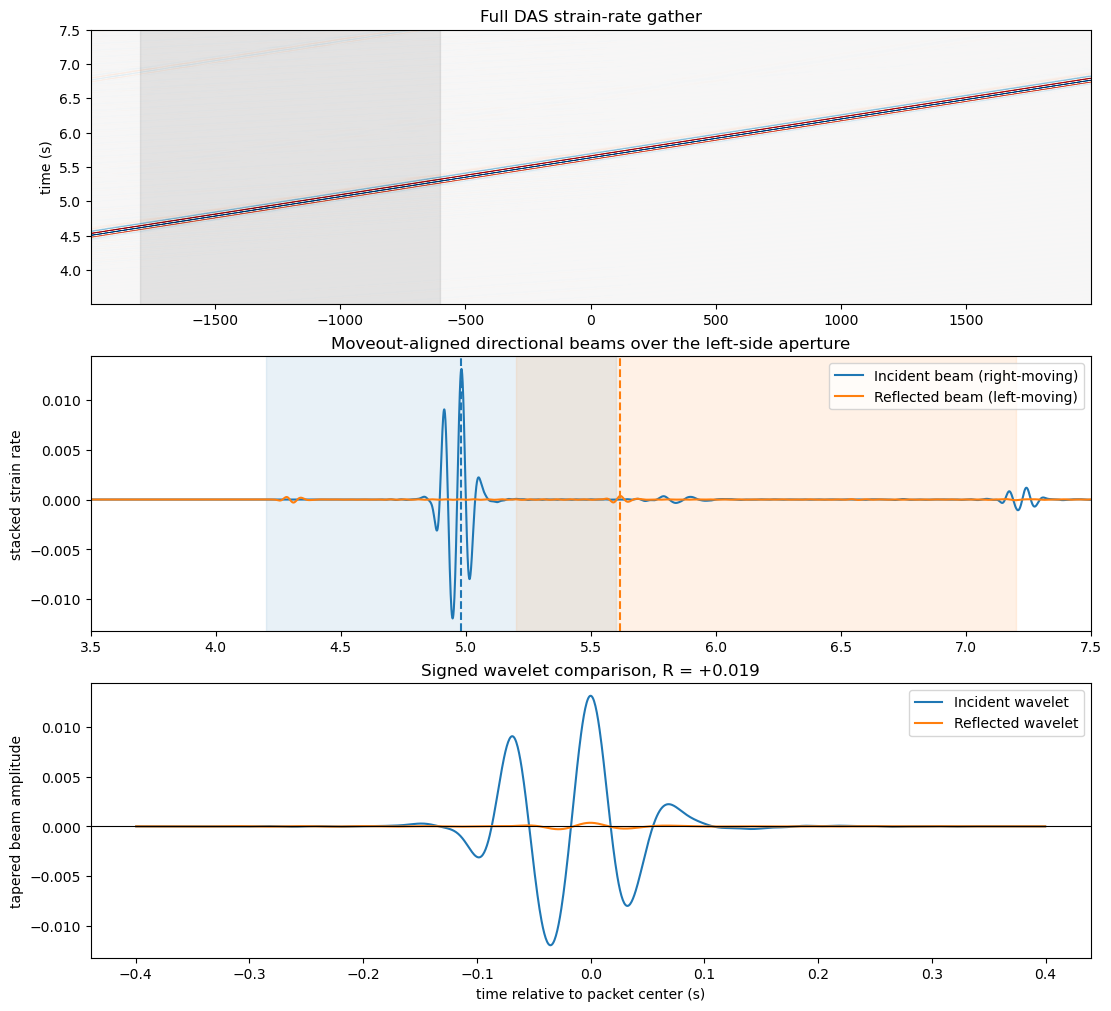

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), constrained_layout=True)
clip = np.percentile(np.abs(das_plot.strain_rate), 99.5)
axes[0].imshow(
    das_plot.strain_rate.T,
    origin='lower',
    aspect='auto',
    extent=[das_plot.x.min(), das_plot.x.max(), das_plot.time.min(), das_plot.time.max()],
    vmin=-clip,
    vmax=clip,
    cmap='RdBu_r',
)
axes[0].axvspan(x_min_m, x_max_m, color='k', alpha=0.08)
axes[0].set_title('Full DAS strain-rate gather')
axes[0].set_ylabel('time (s)')

axes[1].plot(estimate.incident_beam.time, estimate.incident_beam.stack, label='Incident beam (right-moving)')
axes[1].plot(estimate.reflected_beam.time, estimate.reflected_beam.stack, label='Reflected beam (left-moving)')
axes[1].axvspan(*incident_search_window_s, color='C0', alpha=0.1)
axes[1].axvspan(*reflected_search_window_s, color='C1', alpha=0.1)
axes[1].axvline(estimate.incident_center_s, color='C0', ls='--')
axes[1].axvline(estimate.reflected_center_s, color='C1', ls='--')
axes[1].set_xlim(plot_tmin, plot_tmax)
axes[1].set_title('Moveout-aligned directional beams over the left-side aperture')
axes[1].set_ylabel('stacked strain rate')
axes[1].legend(loc='upper right')

axes[2].plot(estimate.time_window_s, estimate.incident_wavelet, label='Incident wavelet')
axes[2].plot(estimate.time_window_s, estimate.reflected_wavelet, label='Reflected wavelet')
axes[2].axhline(0.0, color='k', lw=0.8)
axes[2].set_title(f'Signed wavelet comparison, R = {estimate.coefficient:+.3f}')
axes[2].set_xlabel('time relative to packet center (s)')
axes[2].set_ylabel('tapered beam amplitude')
axes[2].legend(loc='upper right')

plt.show()


In [6]:
# A compact record of the chosen parameters and result.
summary = {
    'phase_velocity_mps': phase_velocity_mps,
    'phase_velocity_halfwidth_mps': phase_velocity_halfwidth_mps,
    'x_min_m': x_min_m,
    'x_max_m': x_max_m,
    'incident_center_s': estimate.incident_center_s,
    'reflected_center_s': estimate.reflected_center_s,
    'reflection_coefficient': estimate.coefficient,
    'correlation': estimate.correlation,
}
summary


{'phase_velocity_mps': 1900.0,
 'phase_velocity_halfwidth_mps': 300.0,
 'x_min_m': -1800.0,
 'x_max_m': -600.0,
 'incident_center_s': 4.983,
 'reflected_center_s': 5.619,
 'reflection_coefficient': 0.019445404587333064,
 'correlation': 0.8520787993897994}